In [30]:
#importar librerias y dataset del titanic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# cargar dataset
dataframe = pd.read_csv("titanic_David_Medina_Ruiz.csv")
dataframe

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,0.0,1.0,0.0,0.271174,0.2,0.000000,0.006369,1.0,0.0
1,1,1.0,0.0,1.0,0.472229,0.2,0.000000,0.132340,0.0,0.0
2,2,1.0,1.0,1.0,0.321438,0.0,0.000000,0.007697,1.0,1.0
3,3,1.0,0.0,1.0,0.434531,0.2,0.000000,0.096569,1.0,0.0
4,4,0.0,1.0,0.0,0.434531,0.0,0.000000,0.007943,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
700,700,0.0,1.0,1.0,0.484795,0.0,0.833333,0.049403,0.5,0.0
701,701,0.0,0.5,0.0,0.334004,0.0,0.000000,0.017681,1.0,1.0
702,702,1.0,0.0,1.0,0.233476,0.0,0.000000,0.051125,1.0,1.0
703,703,1.0,0.0,0.0,0.321438,0.0,0.000000,0.051125,0.0,1.0


In [31]:
X = dataframe.drop(["survived", "Unnamed: 0"], axis=1)
y = dataframe["survived"]

In [32]:
#Los datos ya están escalados, así que categorizamos la y
from tensorflow.keras.utils import to_categorical
y_cod = to_categorical(y)
y_cod

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]])

In [33]:
#Hacemos el train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X, y_cod, test_size=0.25, stratify=y_cod)

In [46]:
from keras.models import Sequential
modelo = Sequential()

#y le añadimos las capas
from keras.layers import Dense #Capa densamente conectada
modelo.add(Dense(500, input_shape=(len(X.columns),) , activation='relu' ))
modelo.add(Dense(2, activation='softmax'))

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
# Configuramos el modelo con el compile
modelo.compile(
    loss = "categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [48]:
h = modelo.fit(
    X_train, 
    y_train, 
    epochs=200,
    batch_size=4,
    validation_data=(X_test,y_test),
    verbose=False
)

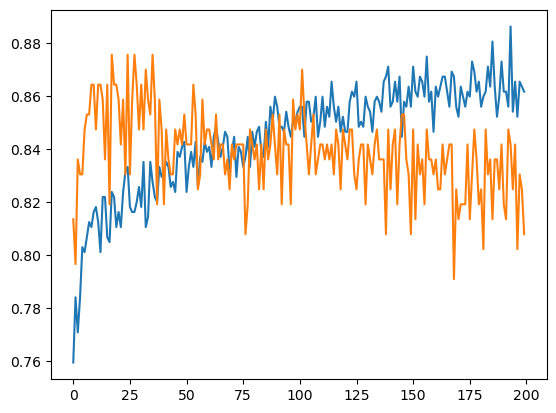

In [49]:
plt.plot(h.history["accuracy"])
plt.plot(h.history["val_accuracy"])